DEVICE: cuda
GPU: Tesla T4

MORPH-DGNet v2 HYPERPARAMETERS
CNN Backbone        : MobileNetV2
Pretrained          : True
Input Size          : 224
Batch Size          : 32
Epochs              : 10
Learning Rate       : 0.0001
Weight Decay        : 0.0001
Validation Split    : 0.2
MobileNet Features  : 1280
ViT Dimension       : 256
ViT Depth           : 6
ViT Heads           : 8
Patch Size          : 16
Morphology Dim      : 128
Fusion Dimension    : 256
Classes             : 3

Extracting dataset...
Dataset extracted.

Dataset root: /content/Potato_Dataset/Potato
Potato___Early_blight: 1000 images
Potato___Late_blight: 1000 images
Potato___healthy: 152 images

Total images: 2152

Training images: 1721
Validation images: 431
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 112MB/s]
/tmp/ipykernel_2829/761034582.py:1187: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(



MORPH-DGNet v2 MODEL
Backbone: MobileNetV2
Pretrained: ImageNet
Total parameters: 8,862,875
Trainable parameters: 8,862,875

MORPH-DGNet v2 TRAINING

Epoch 1/10
Train Loss: 0.4724
Train Accuracy: 90.88%
Validation Loss: 0.3008
Validation Accuracy: 99.77%
Learning Rate: 0.00009755
✓ Best model saved.

Epoch 2/10
Train Loss: 0.3209
Train Accuracy: 98.90%
Validation Loss: 0.2953
Validation Accuracy: 100.00%
Learning Rate: 0.00009045
✓ Best model saved.

Epoch 3/10
Train Loss: 0.3146
Train Accuracy: 99.24%
Validation Loss: 0.2981
Validation Accuracy: 99.77%
Learning Rate: 0.00007939

Epoch 4/10
Train Loss: 0.3102
Train Accuracy: 99.24%
Validation Loss: 0.2963
Validation Accuracy: 99.77%
Learning Rate: 0.00006545

Epoch 5/10
Train Loss: 0.2984
Train Accuracy: 99.94%
Validation Loss: 0.2992
Validation Accuracy: 99.77%
Learning Rate: 0.00005000

Epoch 6/10
Train Loss: 0.3005
Train Accuracy: 99.83%
Validation Loss: 0.2931
Validation Accuracy: 100.00%
Learning Rate: 0.00003455

Epoch 7/10
Trai

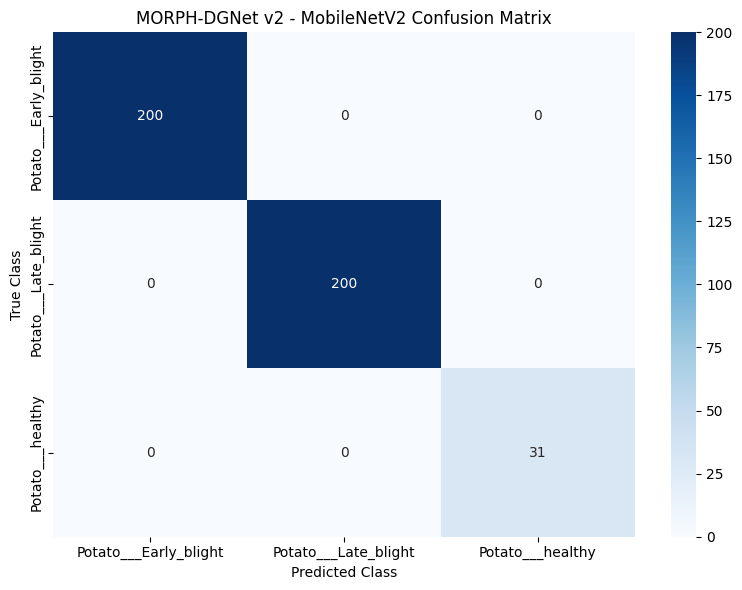

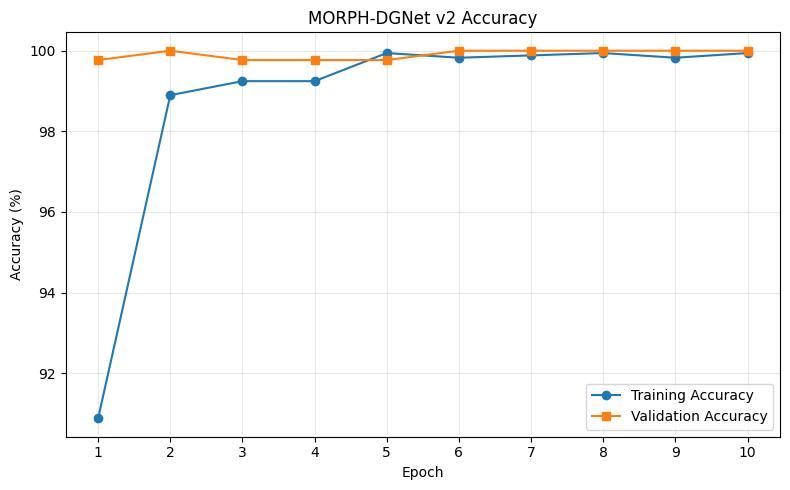

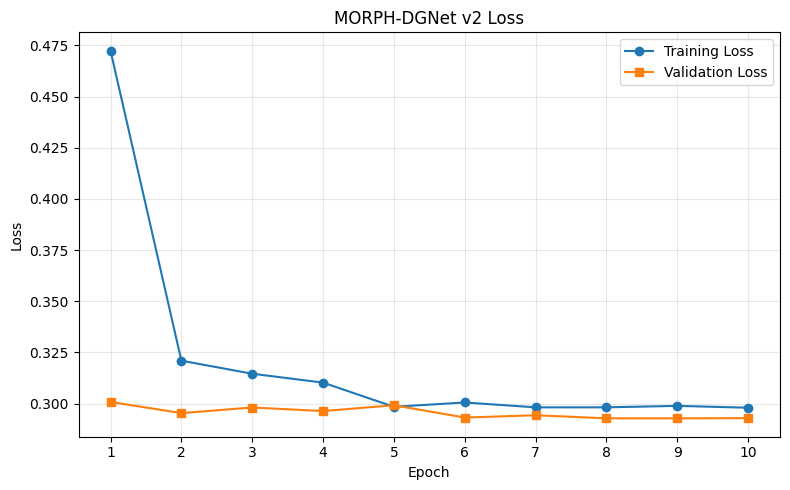


MORPH-DGNet v2 COMPLETE
Model Name       : MORPH-DGNet v2
CNN Backbone     : MobileNetV2
Pretrained       : ImageNet
ViT              : 6 Layers / 8 Heads
ViT Dimension    : 256
Patch Size       : 16
Morphology Dim   : 128
Fusion Dim       : 256
Epochs           : 10
Best Val Acc     : 100.00%

Best model saved:
/content/MORPH_DGNet_v2_MobileNetV2_best.pth

Final model saved:
/content/MORPH_DGNet_v2_MobileNetV2_final.pth



In [ ]:
# ============================================================
# MORPH-DGNet v2
# Morphology-Guided MobileNetV2 + Vision Transformer
# for Potato Leaf Disease Classification
#
# Classes:
#   Potato___Early_blight
#   Potato___Late_blight
#   Potato___healthy
#
# Backbone:
#   MobileNetV2 (ImageNet pretrained)
#
# Input:
#   224 x 224 RGB
#
# Epochs:
#   10
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 3. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("DEVICE:", DEVICE)
print("=" * 70)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 4. DATASET CONFIGURATION
# ============================================================

ZIP_PATH = "/content/Potato.zip"

EXTRACT_DIR = "/content/Potato_Dataset"


CLASS_NAMES = [

    "Potato___Early_blight",

    "Potato___Late_blight",

    "Potato___healthy"

]


CLASS_TO_IDX = {

    class_name: index

    for index, class_name
    in enumerate(CLASS_NAMES)

}


NUM_CLASSES = 3


# ============================================================
# 5. HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 10

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

VAL_SPLIT = 0.20

NUM_WORKERS = 2


# ============================================================
# MobileNetV2
# ============================================================

MOBILENET_PRETRAINED = True

MOBILENET_FEATURE_DIM = 1280


# ============================================================
# ViT
# ============================================================

VIT_DIM = 256

VIT_DEPTH = 6

VIT_HEADS = 8

PATCH_SIZE = 16

VIT_DROPOUT = 0.10


# ============================================================
# Morphology
# ============================================================

MORPH_DIM = 128


# ============================================================
# Fusion
# ============================================================

FUSION_DIM = 256

FUSION_DROPOUT = 0.20

CLASSIFIER_DROPOUT = 0.30


# ============================================================
# 6. PRINT HYPERPARAMETERS
# ============================================================

print("\n" + "=" * 70)
print("MORPH-DGNet v2 HYPERPARAMETERS")
print("=" * 70)

print("CNN Backbone        :", "MobileNetV2")
print("Pretrained          :", MOBILENET_PRETRAINED)
print("Input Size          :", IMAGE_SIZE)
print("Batch Size          :", BATCH_SIZE)
print("Epochs              :", EPOCHS)
print("Learning Rate       :", LEARNING_RATE)
print("Weight Decay        :", WEIGHT_DECAY)
print("Validation Split    :", VAL_SPLIT)
print("MobileNet Features  :", MOBILENET_FEATURE_DIM)
print("ViT Dimension       :", VIT_DIM)
print("ViT Depth           :", VIT_DEPTH)
print("ViT Heads           :", VIT_HEADS)
print("Patch Size          :", PATCH_SIZE)
print("Morphology Dim      :", MORPH_DIM)
print("Fusion Dimension    :", FUSION_DIM)
print("Classes             :", NUM_CLASSES)


# ============================================================
# 7. EXTRACT ZIP DATASET
# ============================================================

if not os.path.exists(ZIP_PATH):

    raise FileNotFoundError(
        f"Dataset not found: {ZIP_PATH}"
    )


if not os.path.exists(EXTRACT_DIR):

    print("\nExtracting dataset...")

    os.makedirs(
        EXTRACT_DIR,
        exist_ok=True
    )

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_DIR
        )

    print("Dataset extracted.")


else:

    print(
        "\nDataset already extracted."
    )


# ============================================================
# 8. FIND DATASET ROOT
# ============================================================

def find_dataset_root(root):

    for current_root, dirs, files in os.walk(root):

        found = 0

        for class_name in CLASS_NAMES:

            class_path = os.path.join(
                current_root,
                class_name
            )

            if os.path.isdir(
                class_path
            ):

                found += 1


        if found == NUM_CLASSES:

            return current_root


    return None


DATASET_ROOT = find_dataset_root(
    EXTRACT_DIR
)


if DATASET_ROOT is None:

    raise RuntimeError(
        "Could not find the three expected class folders."
    )


print(
    "\nDataset root:",
    DATASET_ROOT
)


# ============================================================
# 9. COLLECT IMAGE PATHS
# ============================================================

IMAGE_EXTENSIONS = (

    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"

)


image_paths = []

labels = []


for class_name in CLASS_NAMES:

    class_dir = os.path.join(

        DATASET_ROOT,

        class_name

    )


    class_images = []


    for root, dirs, files in os.walk(
        class_dir
    ):

        for file_name in files:

            if file_name.lower().endswith(
                IMAGE_EXTENSIONS
            ):

                class_images.append(

                    os.path.join(
                        root,
                        file_name
                    )

                )


    print(
        f"{class_name}: "
        f"{len(class_images)} images"
    )


    for path in class_images:

        image_paths.append(
            path
        )

        labels.append(
            CLASS_TO_IDX[class_name]
        )


print(
    "\nTotal images:",
    len(image_paths)
)


# ============================================================
# 10. DATASET CLASS
# ============================================================

class PotatoDataset(Dataset):

    def __init__(

        self,

        image_paths,

        labels,

        transform=None

    ):

        self.image_paths = image_paths

        self.labels = labels

        self.transform = transform


    def __len__(self):

        return len(
            self.image_paths
        )


    def __getitem__(self, index):

        image_path = (
            self.image_paths[index]
        )

        label = (
            self.labels[index]
        )


        image = Image.open(
            image_path
        ).convert("RGB")


        if self.transform is not None:

            image = self.transform(
                image
            )


        return image, label


# ============================================================
# 11. DATA AUGMENTATION
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.2
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(

        brightness=0.15,

        contrast=0.15,

        saturation=0.15,

        hue=0.03

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]

    )

])


val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]

    )

])


# ============================================================
# 12. STRATIFIED TRAIN/VALIDATION SPLIT
# ============================================================

indices = np.arange(
    len(image_paths)
)


labels_array = np.array(
    labels
)


train_indices = []

val_indices = []


for class_id in range(
    NUM_CLASSES
):

    class_indices = indices[
        labels_array == class_id
    ]


    np.random.shuffle(
        class_indices
    )


    split_index = int(

        len(class_indices)
        * (1 - VAL_SPLIT)

    )


    train_indices.extend(

        class_indices[
            :split_index
        ]

    )


    val_indices.extend(

        class_indices[
            split_index:
        ]

    )


random.shuffle(
    train_indices
)

random.shuffle(
    val_indices
)


# ============================================================
# 13. CREATE TRAIN/VAL LISTS
# ============================================================

train_paths = [

    image_paths[i]

    for i in train_indices

]


train_labels = [

    labels[i]

    for i in train_indices

]


val_paths = [

    image_paths[i]

    for i in val_indices

]


val_labels = [

    labels[i]

    for i in val_indices

]


print(
    "\nTraining images:",
    len(train_paths)
)

print(
    "Validation images:",
    len(val_paths)
)


# ============================================================
# 14. DATASETS
# ============================================================

train_dataset = PotatoDataset(

    train_paths,

    train_labels,

    transform=train_transform

)


val_dataset = PotatoDataset(

    val_paths,

    val_labels,

    transform=val_transform

)


# ============================================================
# 15. DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True

)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True

)


# ============================================================
# 16. SE BLOCK
# ============================================================

class SEBlock(nn.Module):

    def __init__(

        self,

        channels,

        reduction=16

    ):

        super().__init__()


        hidden = max(

            channels // reduction,

            4

        )


        self.pool = (
            nn.AdaptiveAvgPool2d(1)
        )


        self.fc = nn.Sequential(

            nn.Linear(

                channels,

                hidden

            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(

                hidden,

                channels

            ),

            nn.Sigmoid()

        )


    def forward(self, x):

        batch_size, channels, _, _ = (
            x.shape
        )


        y = self.pool(
            x
        )


        y = y.view(
            batch_size,
            channels
        )


        y = self.fc(
            y
        )


        y = y.view(

            batch_size,

            channels,

            1,

            1

        )


        return x * y


# ============================================================
# 17. MOBILE NET V2 BACKBONE
# ============================================================

class MobileNetV2Backbone(nn.Module):

    def __init__(

        self,

        pretrained=True

    ):

        super().__init__()


        if pretrained:

            weights = (
                MobileNet_V2_Weights.IMAGENET1K_V1
            )

        else:

            weights = None


        self.model = mobilenet_v2(

            weights=weights

        )


        # Remove original MobileNetV2 classifier

        self.model.classifier = nn.Identity()


        self.out_channels = 1280


    def forward(self, x):

        # Input:
        # B x 3 x 224 x 224
        #
        # Output:
        # B x 1280 x 7 x 7

        x = self.model.features(
            x
        )


        return x


# ============================================================
# 18. DIFFERENTIABLE MORPHOLOGY MODULE
# ============================================================

class MorphologyModule(nn.Module):

    def __init__(

        self,

        in_channels,

        out_channels

    ):

        super().__init__()


        self.projection = nn.Sequential(

            nn.Conv2d(

                in_channels * 4,

                out_channels,

                kernel_size=1,

                bias=False

            ),

            nn.BatchNorm2d(

                out_channels

            ),

            nn.GELU()

        )


        self.se = SEBlock(

            out_channels

        )


    # --------------------------------------------------------
    # Dilation
    # --------------------------------------------------------

    def dilation(self, x):

        return F.max_pool2d(

            x,

            kernel_size=3,

            stride=1,

            padding=1

        )


    # --------------------------------------------------------
    # Erosion
    # --------------------------------------------------------

    def erosion(self, x):

        return -F.max_pool2d(

            -x,

            kernel_size=3,

            stride=1,

            padding=1

        )


    def forward(self, x):

        dilation = self.dilation(
            x
        )


        erosion = self.erosion(
            x
        )


        opening = self.dilation(
            erosion
        )


        closing = self.erosion(
            dilation
        )


        morphology = torch.cat(

            [

                dilation,

                erosion,

                opening,

                closing

            ],

            dim=1

        )


        morphology = self.projection(

            morphology

        )


        morphology = self.se(

            morphology

        )


        return morphology


# ============================================================
# 19. PATCH EMBEDDING
# ============================================================

class PatchEmbedding(nn.Module):

    def __init__(

        self,

        image_size=224,

        patch_size=16,

        in_channels=3,

        embed_dim=256

    ):

        super().__init__()


        assert (

            image_size % patch_size == 0

        )


        self.num_patches = (

            image_size // patch_size

        ) ** 2


        self.projection = nn.Conv2d(

            in_channels,

            embed_dim,

            kernel_size=patch_size,

            stride=patch_size

        )


    def forward(self, x):

        x = self.projection(
            x
        )


        x = x.flatten(
            2
        )


        x = x.transpose(
            1,
            2
        )


        return x


# ============================================================
# 20. VISION TRANSFORMER
# ============================================================

class ViTBranch(nn.Module):

    def __init__(

        self,

        image_size=224,

        patch_size=16,

        embed_dim=256,

        depth=6,

        heads=8,

        mlp_ratio=4.0,

        dropout=0.10

    ):

        super().__init__()


        self.patch_embed = PatchEmbedding(

            image_size=image_size,

            patch_size=patch_size,

            in_channels=3,

            embed_dim=embed_dim

        )


        num_patches = (

            image_size // patch_size

        ) ** 2


        # CLS token

        self.cls_token = nn.Parameter(

            torch.zeros(

                1,

                1,

                embed_dim

            )

        )


        # Position embedding

        self.pos_embed = nn.Parameter(

            torch.zeros(

                1,

                num_patches + 1,

                embed_dim

            )

        )


        self.dropout = nn.Dropout(

            dropout

        )


        encoder_layer = (

            nn.TransformerEncoderLayer(

                d_model=embed_dim,

                nhead=heads,

                dim_feedforward=int(

                    embed_dim * mlp_ratio

                ),

                dropout=dropout,

                activation="gelu",

                batch_first=True,

                norm_first=True

            )

        )


        self.transformer = (

            nn.TransformerEncoder(

                encoder_layer,

                num_layers=depth

            )

        )


        self.norm = nn.LayerNorm(

            embed_dim

        )


        nn.init.trunc_normal_(

            self.pos_embed,

            std=0.02

        )


        nn.init.trunc_normal_(

            self.cls_token,

            std=0.02

        )


    def forward(self, x):

        x = self.patch_embed(
            x
        )


        batch_size = x.shape[0]


        cls_token = (

            self.cls_token.expand(

                batch_size,

                -1,

                -1

            )

        )


        x = torch.cat(

            [

                cls_token,

                x

            ],

            dim=1

        )


        x = (

            x +

            self.pos_embed

        )


        x = self.dropout(
            x
        )


        x = self.transformer(
            x
        )


        x = self.norm(
            x
        )


        # CLS representation

        return x[:, 0]


# ============================================================
# 21. CNN FEATURE PROJECTION
# ============================================================

class CNNProjection(nn.Module):

    def __init__(

        self,

        in_channels=1280,

        out_dim=256

    ):

        super().__init__()


        self.pool = (

            nn.AdaptiveAvgPool2d(1)

        )


        self.fc = nn.Linear(

            in_channels,

            out_dim

        )


    def forward(self, x):

        x = self.pool(
            x
        )


        x = torch.flatten(

            x,

            1

        )


        x = self.fc(
            x
        )


        return x


# ============================================================
# 22. VECTOR SE ATTENTION
# ============================================================

class SEVector(nn.Module):

    def __init__(

        self,

        channels,

        reduction=16

    ):

        super().__init__()


        hidden = max(

            channels // reduction,

            4

        )


        self.fc = nn.Sequential(

            nn.Linear(

                channels,

                hidden

            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(

                hidden,

                channels

            ),

            nn.Sigmoid()

        )


    def forward(self, x):

        attention = self.fc(
            x
        )


        return x * attention


# ============================================================
# 23. MORPHOLOGY-GUIDED FUSION
# ============================================================

class MorphologyGuidedFusion(nn.Module):

    def __init__(

        self,

        cnn_dim=256,

        vit_dim=256,

        morph_dim=128,

        fusion_dim=256

    ):

        super().__init__()


        # CNN projection

        self.cnn_proj = nn.Linear(

            cnn_dim,

            fusion_dim

        )


        # ViT projection

        self.vit_proj = nn.Linear(

            vit_dim,

            fusion_dim

        )


        # Morphology projection

        self.morph_proj = nn.Linear(

            morph_dim,

            fusion_dim

        )


        # Dynamic gate

        self.gate = nn.Sequential(

            nn.Linear(

                fusion_dim * 3,

                fusion_dim

            ),

            nn.GELU(),

            nn.Linear(

                fusion_dim,

                fusion_dim

            ),

            nn.Sigmoid()

        )


        # Fusion layer

        self.fusion = nn.Sequential(

            nn.Linear(

                fusion_dim * 3,

                fusion_dim

            ),

            nn.LayerNorm(

                fusion_dim

            ),

            nn.GELU(),

            nn.Dropout(

                FUSION_DROPOUT

            )

        )


        # SE attention

        self.se = SEVector(

            fusion_dim

        )


    def forward(

        self,

        cnn_features,

        vit_features,

        morph_features

    ):

        cnn = self.cnn_proj(

            cnn_features

        )


        vit = self.vit_proj(

            vit_features

        )


        morph = self.morph_proj(

            morph_features

        )


        # Combined features

        combined = torch.cat(

            [

                cnn,

                vit,

                morph

            ],

            dim=1

        )


        # Morphology-guided gate

        gate = self.gate(

            combined

        )


        # Feature modulation

        cnn_guided = (

            cnn *

            (1.0 + gate)

        )


        vit_guided = (

            vit *

            (1.0 + gate)

        )


        # Final fusion

        fused = torch.cat(

            [

                cnn_guided,

                vit_guided,

                morph

            ],

            dim=1

        )


        fused = self.fusion(
            fused
        )


        fused = self.se(
            fused
        )


        return fused


# ============================================================
# 24. MORPH-DGNet v2 MODEL
# ============================================================

class MORPH_DGNet_v2(nn.Module):

    def __init__(

        self,

        num_classes=3,

        image_size=224,

        vit_dim=256,

        vit_depth=6,

        vit_heads=8,

        patch_size=16,

        fusion_dim=256

    ):

        super().__init__()


        # ====================================================
        # MobileNetV2 Backbone
        # ====================================================

        self.cnn = (

            MobileNetV2Backbone(

                pretrained=True

            )

        )


        cnn_channels = (

            self.cnn.out_channels

        )


        # ====================================================
        # Morphology Module
        # ====================================================

        self.morphology = (

            MorphologyModule(

                in_channels=cnn_channels,

                out_channels=MORPH_DIM

            )

        )


        # ====================================================
        # CNN Projection
        # ====================================================

        self.cnn_projection = (

            CNNProjection(

                in_channels=cnn_channels,

                out_dim=256

            )

        )


        # ====================================================
        # Vision Transformer
        # ====================================================

        self.vit = (

            ViTBranch(

                image_size=image_size,

                patch_size=patch_size,

                embed_dim=vit_dim,

                depth=vit_depth,

                heads=vit_heads,

                dropout=VIT_DROPOUT

            )

        )


        # ====================================================
        # Morphology Pool
        # ====================================================

        self.morph_pool = (

            nn.AdaptiveAvgPool2d(1)

        )


        # ====================================================
        # Morphology-Guided Fusion
        # ====================================================

        self.fusion = (

            MorphologyGuidedFusion(

                cnn_dim=256,

                vit_dim=vit_dim,

                morph_dim=MORPH_DIM,

                fusion_dim=fusion_dim

            )

        )


        # ====================================================
        # Classifier
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Linear(

                fusion_dim,

                fusion_dim // 2

            ),

            nn.LayerNorm(

                fusion_dim // 2

            ),

            nn.GELU(),

            nn.Dropout(

                CLASSIFIER_DROPOUT

            ),

            nn.Linear(

                fusion_dim // 2,

                num_classes

            )

        )


    def forward(self, x):

        # ====================================================
        # STEP 1: MobileNetV2
        # ====================================================

        cnn_features = self.cnn(
            x
        )


        # ====================================================
        # STEP 2: CNN GLOBAL VECTOR
        # ====================================================

        cnn_vector = (

            self.cnn_projection(

                cnn_features

            )

        )


        # ====================================================
        # STEP 3: MORPHOLOGY
        # ====================================================

        morph_features = (

            self.morphology(

                cnn_features

            )

        )


        # ====================================================
        # STEP 4: MORPHOLOGY VECTOR
        # ====================================================

        morph_vector = (

            self.morph_pool(

                morph_features

            )

        )


        morph_vector = torch.flatten(

            morph_vector,

            1

        )


        # ====================================================
        # STEP 5: VISION TRANSFORMER
        # ====================================================

        vit_vector = self.vit(
            x
        )


        # ====================================================
        # STEP 6: MORPHOLOGY-GUIDED FUSION
        # ====================================================

        fused = self.fusion(

            cnn_vector,

            vit_vector,

            morph_vector

        )


        # ====================================================
        # STEP 7: CLASSIFICATION
        # ====================================================

        logits = self.classifier(

            fused

        )


        return logits


# ============================================================
# 25. CREATE MODEL
# ============================================================

model = MORPH_DGNet_v2(

    num_classes=NUM_CLASSES,

    image_size=IMAGE_SIZE,

    vit_dim=VIT_DIM,

    vit_depth=VIT_DEPTH,

    vit_heads=VIT_HEADS,

    patch_size=PATCH_SIZE,

    fusion_dim=FUSION_DIM

).to(DEVICE)


# ============================================================
# 26. MODEL PARAMETERS
# ============================================================

total_params = sum(

    p.numel()

    for p in model.parameters()

)


trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)


print("\n" + "=" * 70)

print("MORPH-DGNet v2 MODEL")

print("=" * 70)

print(
    "Backbone: MobileNetV2"
)

print(
    "Pretrained: ImageNet"
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)


# ============================================================
# 27. LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(

    label_smoothing=0.1

)


# ============================================================
# 28. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)


# ============================================================
# 29. LEARNING RATE SCHEDULER
# ============================================================

scheduler = (

    torch.optim.lr_scheduler.CosineAnnealingLR(

        optimizer,

        T_max=EPOCHS

    )

)


# ============================================================
# 30. TRAIN FUNCTION
# ============================================================

def train_one_epoch(

    model,

    loader,

    criterion,

    optimizer

):

    model.train()


    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in loader:


        images = images.to(

            DEVICE,

            non_blocking=True

        )


        labels = labels.to(

            DEVICE,

            non_blocking=True

        )


        optimizer.zero_grad(

            set_to_none=True

        )


        outputs = model(

            images

        )


        loss = criterion(

            outputs,

            labels

        )


        loss.backward()


        # Gradient clipping

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=1.0

        )


        optimizer.step()


        running_loss += (

            loss.item()

            * images.size(0)

        )


        predictions = (

            outputs.argmax(

                dim=1

            )

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)


    epoch_loss = (

        running_loss /

        total

    )


    epoch_acc = (

        correct /

        total

    )


    return epoch_loss, epoch_acc


# ============================================================
# 31. VALIDATION FUNCTION
# ============================================================

@torch.no_grad()

def validate(

    model,

    loader,

    criterion

):

    model.eval()


    running_loss = 0.0

    correct = 0

    total = 0


    all_predictions = []

    all_labels = []


    for images, labels in loader:


        images = images.to(

            DEVICE,

            non_blocking=True

        )


        labels = labels.to(

            DEVICE,

            non_blocking=True

        )


        outputs = model(

            images

        )


        loss = criterion(

            outputs,

            labels

        )


        running_loss += (

            loss.item()

            * images.size(0)

        )


        predictions = (

            outputs.argmax(

                dim=1

            )

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)


        all_predictions.extend(

            predictions.cpu().numpy()

        )


        all_labels.extend(

            labels.cpu().numpy()

        )


    epoch_loss = (

        running_loss /

        total

    )


    epoch_acc = (

        correct /

        total

    )


    return (

        epoch_loss,

        epoch_acc,

        all_labels,

        all_predictions

    )


# ============================================================
# 32. TRAINING
# ============================================================

best_val_accuracy = 0.0


best_model_path = (

    "/content/"
    "MORPH_DGNet_v2_MobileNetV2_best.pth"

)


history = {

    "train_loss": [],

    "train_accuracy": [],

    "val_loss": [],

    "val_accuracy": []

}


print("\n" + "=" * 70)

print("MORPH-DGNet v2 TRAINING")

print("=" * 70)


for epoch in range(

    EPOCHS

):


    train_loss, train_accuracy = (

        train_one_epoch(

            model,

            train_loader,

            criterion,

            optimizer

        )

    )


    (

        val_loss,

        val_accuracy,

        _,

        _

    ) = validate(

        model,

        val_loader,

        criterion

    )


    scheduler.step()


    # Store history

    history["train_loss"].append(

        train_loss

    )


    history["train_accuracy"].append(

        train_accuracy

    )


    history["val_loss"].append(

        val_loss

    )


    history["val_accuracy"].append(

        val_accuracy

    )


    current_lr = (

        optimizer.param_groups[0]["lr"]

    )


    print(

        f"\nEpoch "

        f"{epoch + 1}/{EPOCHS}"

    )


    print(

        f"Train Loss: "

        f"{train_loss:.4f}"

    )


    print(

        f"Train Accuracy: "

        f"{train_accuracy * 100:.2f}%"

    )


    print(

        f"Validation Loss: "

        f"{val_loss:.4f}"

    )


    print(

        f"Validation Accuracy: "

        f"{val_accuracy * 100:.2f}%"

    )


    print(

        f"Learning Rate: "

        f"{current_lr:.8f}"

    )


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if (

        val_accuracy >

        best_val_accuracy

    ):


        best_val_accuracy = (

            val_accuracy

        )


        torch.save(

            {

                "model_state_dict":

                    model.state_dict(),

                "optimizer_state_dict":

                    optimizer.state_dict(),

                "epoch":

                    epoch + 1,

                "val_accuracy":

                    val_accuracy,

                "class_names":

                    CLASS_NAMES,

                "backbone":

                    "MobileNetV2",

                "model_name":

                    "MORPH-DGNet v2"

            },

            best_model_path

        )


        print(

            "✓ Best model saved."

        )


# ============================================================
# 33. LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(

    best_model_path,

    map_location=DEVICE

)


model.load_state_dict(

    checkpoint[
        "model_state_dict"
    ]

)


print("\n" + "=" * 70)

print("BEST MODEL LOADED")

print("=" * 70)

print(

    f"Best Validation Accuracy: "

    f"{checkpoint['val_accuracy'] * 100:.2f}%"

)


# ============================================================
# 34. FINAL VALIDATION
# ============================================================

(

    final_val_loss,

    final_val_accuracy,

    y_true,

    y_pred

) = validate(

    model,

    val_loader,

    criterion

)


print("\n" + "=" * 70)

print("FINAL RESULTS")

print("=" * 70)


print(

    f"Validation Accuracy: "

    f"{final_val_accuracy * 100:.2f}%"

)


# ============================================================
# 35. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report")

print(

    classification_report(

        y_true,

        y_pred,

        target_names=CLASS_NAMES,

        digits=4

    )

)


# ============================================================
# 36. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_true,

    y_pred,

    labels=np.arange(

        NUM_CLASSES

    )

)


print("\nConfusion Matrix:")

print(cm)


plt.figure(

    figsize=(8, 6)

)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)


plt.xlabel(

    "Predicted Class"

)

plt.ylabel(

    "True Class"

)

plt.title(

    "MORPH-DGNet v2 - MobileNetV2 Confusion Matrix"

)

plt.tight_layout()

plt.show()


# ============================================================
# 37. ACCURACY CURVE
# ============================================================

plt.figure(

    figsize=(8, 5)

)


plt.plot(

    range(

        1,

        EPOCHS + 1

    ),

    np.array(

        history["train_accuracy"]

    ) * 100,

    marker="o",

    label="Training Accuracy"

)


plt.plot(

    range(

        1,

        EPOCHS + 1

    ),

    np.array(

        history["val_accuracy"]

    ) * 100,

    marker="s",

    label="Validation Accuracy"

)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "MORPH-DGNet v2 Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    range(
        1,
        EPOCHS + 1
    )
)

plt.tight_layout()

plt.show()


# ============================================================
# 38. LOSS CURVE
# ============================================================

plt.figure(

    figsize=(8, 5)

)


plt.plot(

    range(

        1,

        EPOCHS + 1

    ),

    history["train_loss"],

    marker="o",

    label="Training Loss"

)


plt.plot(

    range(

        1,

        EPOCHS + 1

    ),

    history["val_loss"],

    marker="s",

    label="Validation Loss"

)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "MORPH-DGNet v2 Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    range(
        1,
        EPOCHS + 1
    )
)

plt.tight_layout()

plt.show()


# ============================================================
# 39. SINGLE IMAGE PREDICTION
# ============================================================

def predict_potato(

    image_path,

    model

):


    model.eval()


    image = Image.open(

        image_path

    ).convert("RGB")


    image_tensor = val_transform(

        image

    )


    image_tensor = (

        image_tensor

        .unsqueeze(0)

        .to(DEVICE)

    )


    with torch.no_grad():


        outputs = model(

            image_tensor

        )


        probabilities = (

            torch.softmax(

                outputs,

                dim=1

            )

        )


        predicted_class = (

            probabilities.argmax(

                dim=1

            ).item()

        )


    print("\n" + "=" * 60)

    print("MORPH-DGNet v2 PREDICTION")

    print("=" * 60)


    print(

        "Predicted Disease:",

        CLASS_NAMES[
            predicted_class
        ]

    )


    print(

        "Confidence:",

        f"{probabilities[0, predicted_class].item() * 100:.2f}%"

    )


    print("\nClass probabilities:")


    for i, class_name in enumerate(

        CLASS_NAMES

    ):


        print(

            f"{class_name}: "

            f"{probabilities[0, i].item() * 100:.2f}%"

        )


    return (

        CLASS_NAMES[predicted_class],

        probabilities[0].cpu().numpy()

    )


# ============================================================
# 40. SAVE FINAL MODEL
# ============================================================

final_model_path = (

    "/content/"
    "MORPH_DGNet_v2_MobileNetV2_final.pth"

)


torch.save(

    {

        "model_state_dict":

            model.state_dict(),

        "model_name":

            "MORPH-DGNet v2",

        "backbone":

            "MobileNetV2",

        "pretrained":

            True,

        "class_names":

            CLASS_NAMES,

        "image_size":

            IMAGE_SIZE,

        "batch_size":

            BATCH_SIZE,

        "epochs":

            EPOCHS,

        "learning_rate":

            LEARNING_RATE,

        "weight_decay":

            WEIGHT_DECAY,

        "validation_split":

            VAL_SPLIT,

        "vit_dim":

            VIT_DIM,

        "vit_depth":

            VIT_DEPTH,

        "vit_heads":

            VIT_HEADS,

        "patch_size":

            PATCH_SIZE,

        "morphology_dimension":

            MORPH_DIM,

        "fusion_dimension":

            FUSION_DIM,

        "best_validation_accuracy":

            best_val_accuracy

    },

    final_model_path

)


# ============================================================
# 41. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)

print("MORPH-DGNet v2 COMPLETE")

print("=" * 70)

print(
    "Model Name       : MORPH-DGNet v2"
)

print(
    "CNN Backbone     : MobileNetV2"
)

print(
    "Pretrained       : ImageNet"
)

print(
    "ViT              : 6 Layers / 8 Heads"
)

print(
    "ViT Dimension    :", VIT_DIM
)

print(
    "Patch Size       :", PATCH_SIZE
)

print(
    "Morphology Dim   :", MORPH_DIM
)

print(
    "Fusion Dim       :", FUSION_DIM
)

print(
    "Epochs           :", EPOCHS
)

print(
    f"Best Val Acc     : "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "\nBest model saved:"
)

print(
    best_model_path
)

print(
    "\nFinal model saved:"
)

print(
    final_model_path
)

print("\n" + "=" * 70)

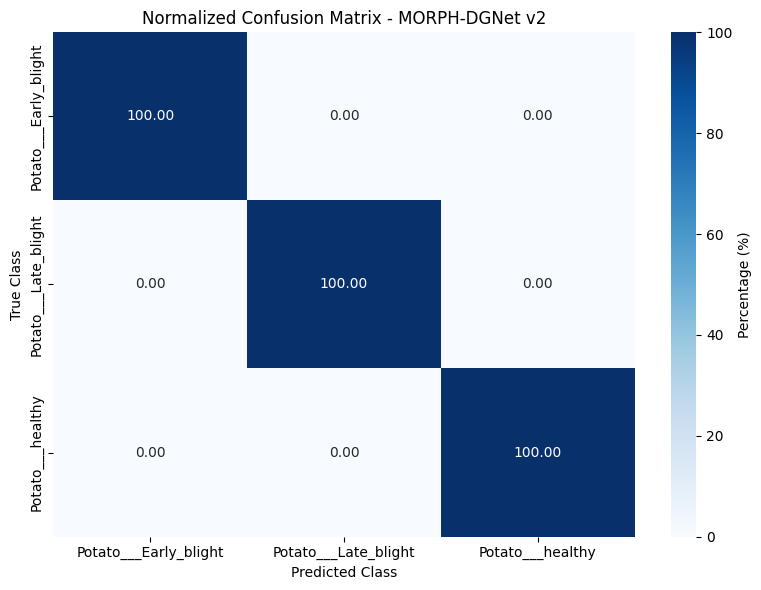

In [ ]:
# ============================================================
# NORMALIZED CONFUSION MATRIX
# MORPH-DGNet v2
# ============================================================

from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Generate confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

# ------------------------------------------------------------
# Normalize row-wise
# Each row = 100%
# ------------------------------------------------------------

cm_normalized = cm.astype(float) / cm.sum(
    axis=1,
    keepdims=True
)

# Convert to percentage
cm_percentage = cm_normalized * 100

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_percentage,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    vmin=0,
    vmax=100,
    cbar_kws={
        "label": "Percentage (%)"
    }
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    "Normalized Confusion Matrix - MORPH-DGNet v2"
)

plt.tight_layout()

plt.show()

Test dataset ready.

TEST PATH:
/content/Potato_Plantdoc/Potato_Plantdoc/test
Potato leaf early blight: 8 images
Potato leaf late blight: 8 images

Total test images: 16

Test samples: 16

Best MORPH-DGNet v2 model loaded.

MORPH-DGNet v2 - PlantDoc TEST RESULTS
Correct predictions : 10
Total test images   : 16
TEST ACCURACY       : 62.50%

Classification Report:
                          precision    recall  f1-score   support

Potato leaf early blight     0.6000    0.7500    0.6667         8
 Potato leaf late blight     0.6667    0.5000    0.5714         8

                accuracy                         0.6250        16
               macro avg     0.6333    0.6250    0.6190        16
            weighted avg     0.6333    0.6250    0.6190        16


Confusion Matrix:
[[6 2]
 [4 4]]


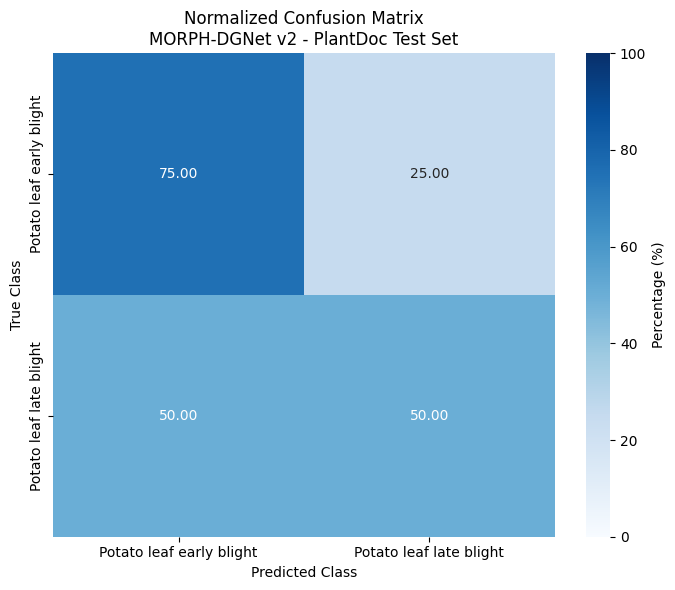


Per-Class Test Accuracy:
Potato leaf early blight: 75.00%
Potato leaf late blight: 50.00%

FINAL TEST SUMMARY
Model       : MORPH-DGNet v2
Backbone    : MobileNetV2
Test Dataset: PlantDoc
Test Folder : Potato_Plantdoc/test
Test Classes: Early Blight + Late Blight
Test Accuracy: 62.50%


In [ ]:
# ============================================================
# MORPH-DGNet v2
# TESTING USING UPLOADED POTATO_PLANTDOC.ZIP
# ============================================================

import os
import zipfile
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. TEST ZIP PATH
# ============================================================

TEST_ZIP = "/content/Potato_Plantdoc.zip"

TEST_EXTRACT_DIR = "/content/Potato_Plantdoc"


# ============================================================
# 2. EXTRACT TEST DATASET
# ============================================================

if not os.path.exists(TEST_EXTRACT_DIR):

    os.makedirs(
        TEST_EXTRACT_DIR,
        exist_ok=True
    )

    with zipfile.ZipFile(
        TEST_ZIP,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            TEST_EXTRACT_DIR
        )

print("Test dataset ready.")


# ============================================================
# 3. EXACT TEST PATH
# ============================================================

TEST_DIR = os.path.join(
    TEST_EXTRACT_DIR,
    "Potato_Plantdoc",
    "test"
)

# If extraction creates only Potato_Plantdoc/test
if not os.path.exists(TEST_DIR):

    TEST_DIR = os.path.join(
        TEST_EXTRACT_DIR,
        "test"
    )


print("\nTEST PATH:")
print(TEST_DIR)


if not os.path.exists(TEST_DIR):

    raise FileNotFoundError(
        f"Test folder not found: {TEST_DIR}"
    )


# ============================================================
# 4. TEST CLASS MAPPING
# ============================================================

TEST_CLASSES = {

    "Potato leaf early blight": 0,

    "Potato leaf late blight": 1

}


TEST_CLASS_NAMES = [

    "Potato leaf early blight",

    "Potato leaf late blight"

]


# ============================================================
# 5. COLLECT TEST IMAGES
# ============================================================

test_paths = []
test_labels = []


IMAGE_EXTENSIONS = (

    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"

)


for class_name, class_id in TEST_CLASSES.items():

    class_folder = os.path.join(
        TEST_DIR,
        class_name
    )


    if not os.path.exists(class_folder):

        print(
            "WARNING: Folder not found:",
            class_folder
        )

        continue


    count = 0


    for root, dirs, files in os.walk(
        class_folder
    ):

        for file_name in files:

            if file_name.lower().endswith(
                IMAGE_EXTENSIONS
            ):

                test_paths.append(

                    os.path.join(
                        root,
                        file_name
                    )

                )

                test_labels.append(
                    class_id
                )

                count += 1


    print(
        f"{class_name}: {count} images"
    )


print(
    "\nTotal test images:",
    len(test_paths)
)


# ============================================================
# 6. TEST TRANSFORM
# ============================================================

test_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]

    )

])


# ============================================================
# 7. TEST DATASET
# ============================================================

class PlantDocTestDataset(Dataset):

    def __init__(
        self,
        paths,
        labels,
        transform=None
    ):

        self.paths = paths

        self.labels = labels

        self.transform = transform


    def __len__(self):

        return len(
            self.paths
        )


    def __getitem__(self, index):

        image = Image.open(

            self.paths[index]

        ).convert("RGB")


        if self.transform:

            image = self.transform(
                image
            )


        label = self.labels[index]


        return image, label


# ============================================================
# 8. CREATE TEST LOADER
# ============================================================

test_dataset = PlantDocTestDataset(

    test_paths,

    test_labels,

    test_transform

)


test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)


print(
    "\nTest samples:",
    len(test_dataset)
)


# ============================================================
# 9. IMPORTANT
# ============================================================
# Your MORPH-DGNet v2 was trained with:
#
# 0 = Potato___Early_blight
# 1 = Potato___Late_blight
# 2 = Potato___healthy
#
# PlantDoc test contains only:
#
# 0 = Early blight
# 1 = Late blight
#
# Therefore we evaluate only predictions 0 and 1.
# ============================================================


# ============================================================
# 10. LOAD BEST TRAINED MODEL
# ============================================================

BEST_MODEL_PATH = (
    "/content/"
    "MORPH_DGNet_v2_MobileNetV2_best.pth"
)


if os.path.exists(BEST_MODEL_PATH):

    checkpoint = torch.load(

        BEST_MODEL_PATH,

        map_location=DEVICE

    )


    model.load_state_dict(

        checkpoint[
            "model_state_dict"
        ]

    )


    print(
        "\nBest MORPH-DGNet v2 model loaded."
    )

else:

    print(
        "\nBest model file not found."
    )

    print(
        "Using the currently trained model."
    )


model = model.to(
    DEVICE
)

model.eval()


# ============================================================
# 11. TESTING
# ============================================================

all_test_labels = []

all_test_predictions = []


correct = 0

total = 0


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        outputs = model(
            images
        )


        # ----------------------------------------------------
        # Only first two classes are valid for this test set
        # ----------------------------------------------------

        outputs_2class = outputs[:, :2]


        predictions = outputs_2class.argmax(
            dim=1
        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)


        all_test_labels.extend(

            labels.cpu().numpy()

        )


        all_test_predictions.extend(

            predictions.cpu().numpy()

        )


# ============================================================
# 12. TEST ACCURACY
# ============================================================

test_accuracy = (

    correct / total

)


print("\n" + "=" * 70)

print(
    "MORPH-DGNet v2 - PlantDoc TEST RESULTS"
)

print("=" * 70)

print(
    f"Correct predictions : {correct}"
)

print(
    f"Total test images   : {total}"
)

print(
    f"TEST ACCURACY       : "
    f"{test_accuracy * 100:.2f}%"
)

print("=" * 70)


# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(

    classification_report(

        all_test_labels,

        all_test_predictions,

        labels=[0, 1],

        target_names=TEST_CLASS_NAMES,

        digits=4,

        zero_division=0

    )

)


# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    all_test_labels,

    all_test_predictions,

    labels=[0, 1]

)


print("\nConfusion Matrix:")

print(cm)


# ============================================================
# 15. NORMALIZED CONFUSION MATRIX
# ============================================================

cm_normalized = (

    cm.astype(float)

    /

    cm.sum(
        axis=1,
        keepdims=True
    )

)


cm_percentage = (

    cm_normalized * 100

)


plt.figure(

    figsize=(7, 6)

)


sns.heatmap(

    cm_percentage,

    annot=True,

    fmt=".2f",

    cmap="Blues",

    xticklabels=TEST_CLASS_NAMES,

    yticklabels=TEST_CLASS_NAMES,

    vmin=0,

    vmax=100,

    cbar_kws={
        "label": "Percentage (%)"
    }

)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "Normalized Confusion Matrix\n"
    "MORPH-DGNet v2 - PlantDoc Test Set"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. PER-CLASS ACCURACY
# ============================================================

print("\nPer-Class Test Accuracy:")

for i, class_name in enumerate(
    TEST_CLASS_NAMES
):

    class_total = np.sum(
        np.array(all_test_labels) == i
    )

    class_correct = np.sum(

        (

            np.array(all_test_labels) == i

        )

        &

        (

            np.array(all_test_predictions) == i

        )

    )


    if class_total > 0:

        class_accuracy = (

            class_correct /

            class_total

        ) * 100

    else:

        class_accuracy = 0


    print(

        f"{class_name}: "
        f"{class_accuracy:.2f}%"

    )


# ============================================================
# 17. FINAL TEST SUMMARY
# ============================================================

print("\n" + "=" * 70)

print("FINAL TEST SUMMARY")

print("=" * 70)

print(
    "Model       : MORPH-DGNet v2"
)

print(
    "Backbone    : MobileNetV2"
)

print(
    "Test Dataset: PlantDoc"
)

print(
    "Test Folder : Potato_Plantdoc/test"
)

print(
    "Test Classes: Early Blight + Late Blight"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print("=" * 70)